# MLP para reconocimiento de paisajes

Proyecto de **Machine Learning** en el que se entrena un **Perceptrón Multicapa (MLP)**, un tipo de red neuronal, para clasificar imágenes de paisajes en 6 categorías. Se usa `TensorFlow`/`Keras` para cargar y procesar las imágenes, y `Matplotlib`/`Seaborn` para graficar los resultados.

## Integrantes :
- Gabriel Duran
- Martin Higura
- Francisco Salazar

## 2. Problema de negocio y propuesta

### a. Contexto del problema

Se necesita un modelo de inteligencia artificial capaz de recibir una fotografía de un paisaje y decir a qué categoría pertenece entre 6 opciones: edificios, bosques, glaciares, montañas, mar y calles. Este tipo de problema se llama **clasificación de imágenes**: el modelo no "ve" como nosotros, sino que recibe una matriz de números (los píxeles) y debe aprender qué números suelen aparecer en cada paisaje.

Las imágenes originales miden **256x256 píxeles y tienen 3 canales de color (RGB)**, es decir, 256×256×3 = **196.608 números** por foto. La red debe resumir toda esa información para decidir entre 6 respuestas posibles.

### b. Importancia para el negocio

Clasificar paisajes de forma automática tiene valor en varios rubros:

*   **Turismo:** recomendar destinos según el tipo de paisaje de una foto.
*   **Medio ambiente:** monitorear bosques, glaciares o el mar de forma automática.
*   **Redes sociales:** etiquetar fotos para poder buscarlas mejor.
*   **Ciudades inteligentes:** distinguir zonas urbanas (calles, edificios) de zonas naturales.

Hacerlo de forma manual con miles de fotos es lento y costoso. Un modelo entrenado puede clasificar las imágenes en segundos, por eso la propuesta de este notebook es construir ese modelo y medir con métricas qué tan bien lo hace.

## 3. Selección y descripción del dataset

### a. Dataset utilizado

Se utilizó el dataset **Intel Image Classification**, un conjunto de imágenes de paisajes naturales y urbanos muy usado para aprender Machine Learning. Viene organizado en tres carpetas según su propósito:

*   `seg_train`: imágenes **etiquetadas** para entrenar al modelo (tienen subcarpetas por clase).
*   `seg_test`: imágenes **etiquetadas** para la prueba final ("examen") del modelo.
*   `seg_pred`: imágenes **sin etiqueta** que servirían para predicciones sobre fotos nuevas.

### b. Cantidad de imágenes

En total hay aproximadamente **25.000 imágenes**, repartidas así:

*   `seg_train`: **14.034** imágenes.
*   `seg_test`: **3.000** imágenes.
*   `seg_pred`: **7.301** imágenes.

*Las cantidades exactas se verifican con código en el análisis exploratorio.*

### c. Número de clases

El dataset tiene **6 clases** (categorías), que son los 6 tipos de paisaje que el modelo debe distinguir:

1.  `buildings` (edificios)
2.  `forest` (bosque)
3.  `glacier` (glaciar)
4.  `mountain` (montaña)
5.  `sea` (mar)
6.  `street` (calle)

Como hay 6 categorías, la capa de salida del modelo tendrá 6 neuronas.

### d. Características principales

*   **Formato:** imágenes `.jpg`.
*   **Resolución original:** 256x256 píxeles (se confirma con código más adelante).
*   **Canales:** 3 canales de color (RGB).
*   **Organización:** una subcarpeta por clase dentro de `seg_train` y `seg_test`.
*   **Etiquetado:** el nombre de cada subcarpeta ES la clase de las fotos que contiene.

### e. Justificación de selección

Elegimos este dataset porque:

*   Es **variado**: mezcla zonas naturales y urbanas, por lo que el modelo debe aprender patrones distintos (colores, formas y texturas).
*   Está **bien etiquetado**: las carpetas ya llevan el nombre de la clase, no hay que etiquetar a mano.
*   Es de **tamaño razonable**: ~25.000 imágenes permiten aprender sin necesitar un supercomputador.
*   Permite recorrer el **ciclo completo** de un proyecto de ML: analizar, preprocesar, entrenar y evaluar.

## 4. Análisis exploratorio de imágenes (EDA)

Antes de entrenar, conviene *conocer* los datos: cuántas fotos hay por clase, qué resolución tienen y qué tan parecidas o diferentes son. Eso es exactamente lo que se hace en un análisis exploratorio.

### a. Distribución de clases

¿Hay la misma cantidad de fotos en cada clase? Si una clase tuviera muchísimas más fotos, el modelo podría "copiar" la clase más común y olvidarse del resto. Lo verificamos con código.

In [ ]:
import os

# rutas
ruta_original = os.path.join("dataset", "Intel Image Classification")
ruta_train_original = os.path.join(ruta_original, "seg_train", "seg_train")
ruta_test_original = os.path.join(ruta_original, "seg_test", "seg_test")

# Listamos las 6 clases
clases = sorted(os.listdir(ruta_train_original))
print("Clases encontradas:", clases, "\n")

# diccionarios 
conteo_train = {}
conteo_test = {}
for clase in clases:
    conteo_train[clase] = len(os.listdir(os.path.join(ruta_train_original, clase)))
    conteo_test[clase] = len(os.listdir(os.path.join(ruta_test_original, clase)))
    print(f"{clase:10s} -> train: {conteo_train[clase]:5d} | test: {conteo_test[clase]:5d}")

print("\nTotales:")
print(f"  Train: {sum(conteo_train.values())}")
print(f"  Test:  {sum(conteo_test.values())}")
print(f"  Pred:  {len(os.listdir(os.path.join(ruta_original, 'seg_pred', 'seg_pred')))}")

Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'] 

buildings  -> train:  2191 | test:   437
forest     -> train:  2271 | test:   474
glacier    -> train:  2404 | test:   553
mountain   -> train:  2512 | test:   525
sea        -> train:  2274 | test:   510
street     -> train:  2382 | test:   501

Totales:
  Train: 14034
  Test:  3000
  Pred:  7301


**Resultado:** las 6 clases tienen una cantidad **muy parecida** de imágenes (entre ~2.200 y ~2.500 en train, y ~450–550 en test). No hay un desbalanceo importante, por lo que **no hace falta balancear** las clases.

### b. Resolución y canales

Aquí verificamos el **tamaño real** de las imágenes y que sean a color. Usamos el cargador de TensorFlow `image_dataset_from_directory`, que convierte cada subcarpeta en lotes de tensores. Cargamos **sin redimensionar** para ver la resolución original del dataset.

In [ ]:
import tensorflow as tf

# lotes sin  redimensionar para ver la resolución real de las fotos
ds_prueba_resolucion = tf.keras.utils.image_dataset_from_directory(
    ruta_test_original,
    batch_size=32
)

for imagenes, _ in ds_prueba_resolucion.take(1):
    print("Forma de un lote completo:", imagenes.shape)
    print("Forma de una sola imagen:", imagenes[0].shape)
    print("Tipo de datos (dtype):", imagenes.dtype)
    break

Found 3000 files belonging to 6 classes.
Forma de un lote completo: (32, 256, 256, 3)
Forma de una sola imagen: (256, 256, 3)
Tipo de datos (dtype): <dtype: 'float32'>


**Resultado:** cada lote tiene forma `(32, 256, 256, 3)`: 32 imágenes de **256x256** píxeles con **3 canales** (RGB, o sea a color). El `dtype` es `float32`, lo que significa que los píxeles se manejan como números decimales.

### c. Patrones visuales

Al observar las fotos de cada clase se distinguen patrones típicos:

*   **buildings**: predominan líneas rectas y formas rectangulares (ventanas, paredes).
*   **forest**: domina el color verde en distintas tonalidades, con troncos o ramas.
*   **glacier**: blancos, azules y celestes, con formas más curvas.
*   **mountain**: se ven picos o formas triangulares.
*   **sea**: distintas tonalidades de azul y pocas figuras definidas.
*   **street**: espacios angostos con objetos urbanos y, a veces, personas.

### d. Variabilidad encontrada

Dentro de una misma clase hay variabilidad: distintas horas de luz, ángulos, estaciones y cercanía. Por ejemplo, algunas fotos de `glacier` se parecen a `sea` por el color azul, y algunas de `mountain` pueden parecerse a `forest` si hay muchos árboles. Esa variabilidad es normal y será uno de los grandes retos del modelo.

## 5. Preprocesamiento de datos

### a. Carga y limpieza

Para no dañar el dataset original, primero creamos una **copia de seguridad** con `shutil`. Todo el preprocesamiento se hará sobre la **copia**, así la fuente original queda intacta y siempre podemos volver a ella.

In [3]:
import os
import shutil

ruta_origen = os.path.join("dataset", "Intel Image Classification")
ruta_copia = os.path.join("copy", "Intel Image Classification")

if os.path.exists(ruta_copia):
    print("La copia ya existe. La reutilizamos para no duplicar el trabajo.")
else:
    print("Creando copia del dataset (esto puede tardar unos segundos)...")
    os.makedirs("copy", exist_ok=True)
    shutil.copytree(ruta_origen, ruta_copia)
    print("Copia creada correctamente.")

La copia ya existe. La reutilizamos para no duplicar el trabajo.


A partir de aquí, las rutas apuntan a la **copia** y no a la fuente original.

In [4]:
# Redirigimos las rutas de trabajo hacia la copia
ruta_train = os.path.join(ruta_copia, "seg_train", "seg_train")
ruta_test = os.path.join(ruta_copia, "seg_test", "seg_test")

print("Ruta train (copia):", ruta_train)
print("Ruta test  (copia):", ruta_test)

Ruta train (copia): copy\Intel Image Classification\seg_train\seg_train
Ruta test  (copia): copy\Intel Image Classification\seg_test\seg_test


Ahora limpiamos la copia: recorremos todos los archivos y nos quedamos solo con imágenes (extensiones `.jpg`, `.jpeg` y `.png`). Cualquier otro archivo se elimina para que el cargador no falle.

In [5]:
import os

extensiones_validas = {'.jpg', '.jpeg', '.png'}
archivos_eliminados = 0

for ruta_carpeta in [ruta_train, ruta_test]:
    for clase in os.listdir(ruta_carpeta):
        ruta_clase = os.path.join(ruta_carpeta, clase)
        if not os.path.isdir(ruta_clase):
            continue
        for archivo in os.listdir(ruta_clase):
            _, extension = os.path.splitext(archivo)
            if extension.lower() not in extensiones_validas:
                os.remove(os.path.join(ruta_clase, archivo))
                print("Archivo inválido eliminado:", archivo)
                archivos_eliminados += 1

print(f"Limpieza finalizada. Archivos inválidos eliminados: {archivos_eliminados}")

Limpieza finalizada. Archivos inválidos eliminados: 0


### b. Redimensionamiento

Las fotos originales miden **256x256**, pero para un MLP reducir el tamaño es una gran ventaja: las reducimos a **64x64** con `image_size=(64, 64)`.

*   Con 256x256, la entrada tendría 256×256×3 = **196.608 valores** y la primera capa oculta ~100,7 millones de parámetros: demasiado pesada y muy propensa a memorizar (overfitting).
*   Con 64x64 quedan 64×64×3 = **12.288 valores** y ~6,3 millones de parámetros: entrena más rápido, ocupa menos memoria (importante en esta PC) y sobreajusta menos.

Además, el redimensionamiento garantiza que todas las fotos entren a la red con **exactamente la misma forma**, tal como la red lo exige.

In [6]:
import tensorflow as tf

# Demostración: cargamos la copia ya redimensionada a 64x64
ds_demo = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=(64, 64),
    batch_size=32
)

for imagenes, _ in ds_demo.take(1):
    print("Forma del lote redimensionado:", imagenes.shape)
    break

Found 3000 files belonging to 6 classes.
Forma del lote redimensionado: (32, 64, 64, 3)


### c. Normalización

Los píxeles van de 0 a 255, pero las redes aprenden **mucho mejor con números pequeños y parecidos**. Por eso dividimos cada píxel entre 255 con `Rescaling(1/255)`: todos los valores quedan entre **0 y 1**.

In [7]:
# Capa que normaliza: divide cada píxel entre 255 (máximo valor de RGB)
normalizador = tf.keras.layers.Rescaling(1. / 255)

for imagenes, _ in ds_demo.take(1):
    pixel_original = imagenes[0][0][0].numpy()
    pixel_normalizado = normalizador(imagenes)[0][0][0].numpy()
    print("Primer píxel SIN normalizar:", pixel_original)
    print("Primer píxel  normalizado  :", pixel_normalizado)
    break

Primer píxel SIN normalizar: [ 85. 125. 184.]
Primer píxel  normalizado  : [0.33333334 0.4901961  0.72156864]


**Resultado:** el píxel pasó de **85** a **0.33333334** (85 ÷ 255), quedando como un **decimal entre 0 y 1**. Con estos números la red aprende de forma más estable y rápida.

### d. Etiquetado

Keras asigna automáticamente un **número entero (etiqueta)** a cada clase, usando el nombre de las subcarpetas en orden alfabético:

*   0 -> `buildings`
*   1 -> `forest`
*   2 -> `glacier`
*   3 -> `mountain`
*   4 -> `sea`
*   5 -> `street`

El modelo no devuelve "forest": devuelve **6 probabilidades**, y nosotros elegimos la clase con la probabilidad más alta.

In [8]:
# Keras guarda el nombre de cada clase en .class_names
print("Etiqueta (entero) -> Clase")
for indice, nombre in enumerate(ds_demo.class_names):
    print(f"  {indice} -> {nombre}")

for _, etiquetas in ds_demo.take(1):
    print("\nMuestra de etiquetas de un lote:", etiquetas.numpy()[:10])
    break

Etiqueta (entero) -> Clase
  0 -> buildings
  1 -> forest
  2 -> glacier
  3 -> mountain
  4 -> sea
  5 -> street

Muestra de etiquetas de un lote: [5 1 2 2 4 5 0 3 1 5]


### e. Train / Validation / Test

Dividimos los datos en 2 grupos para que la evaluación sea **honesta**:

*   **Train (100% de seg_train):** las **14.034** fotos con las que el modelo estudia y ajusta sus pesos.
*   **Validation / Test (100% de seg_test):** las **3.000** fotos del "examen final": el modelo las usa como "ensayo" al final de cada época y **nunca** ajusta sus pesos con ellas.

No se recorta un 80/20 a mano: `seg_train` se usa entero para estudiar y `seg_test` entero para validar y, al final, evaluar.

In [9]:
import tensorflow as tf

TAMANO = (64, 64)      # redimensionamiento a 64x64 (transformacion)
BATCH = 32             # lotes de 32 imágenes 

# 1. 100% de la carpeta seg_train para entrenar
dataset_train = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    image_size=TAMANO,
    batch_size=BATCH,
    shuffle=True       # Mezclamos las fotos para que el modelo no memorice el orden
)

# 2. 100% de la carpeta seg_test para validar el aprendizaje
dataset_test = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=TAMANO,
    batch_size=BATCH,
    shuffle=False      
)

print("\nConjuntos listos:")
print("  Train:", len(dataset_train), "lotes")
print("  Validación:", len(dataset_test), "lotes")
print("  Clases:", dataset_train.class_names)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.

Conjuntos listos:
  Train: 439 lotes
  Validación: 94 lotes
  Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Se cargaron los dos conjuntos **por lotes de 32 imágenes** (`batch_size=32`): en memoria nunca está todo el dataset de golpe, lo que **protege la RAM** de la PC.

Sobre estos lotes aplicamos dos transformaciones a los datos de **entrenamiento**:

1.  **Normalización** con `Rescaling`: píxeles entre 0 y 1.
2.  **Aumento de datos**: voltear horizontalmente, rotar levemente y hacer zoom pequeño, de forma aleatoria en cada época. Así la red nunca ve dos veces exactamente la misma foto y aprende a **generalizar** (reduce el overfitting).

La **validación/test** solo se normaliza, para evaluar con las fotos reales, sin alteraciones.

In [10]:
normalizador = tf.keras.layers.Rescaling(1. / 255)

# Aumento de datos: SOLO se aplica al entrenamiento
aumento_datos = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),  # volteo horizontal aleatorio
    tf.keras.layers.RandomRotation(0.05),      # rotación leve aleatoria
    tf.keras.layers.RandomZoom(0.05),          # zoom leve aleatorio
], name="Aumento_de_datos")

def preparar_entrenamiento(imagen, etiqueta):
    imagen = normalizador(imagen)   # píxeles a [0,1]
    imagen = aumento_datos(imagen)  # variación aleatoria
    return imagen, etiqueta

def preparar_evaluacion(imagen, etiqueta):
    imagen = normalizador(imagen)   # solo normalizar
    return imagen, etiqueta

dataset_train_prep = dataset_train.map(
    preparar_entrenamiento, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
dataset_test_prep = dataset_test.map(
    preparar_evaluacion, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

print("Pipeline listo: train con normalización + aumento, val/test solo con normalización.")

Pipeline listo: train con normalización + aumento, val/test solo con normalización.


In [11]:
# Verificamos que los datos de entrenamiento ya estén normalizados (0 a 1)
for imagenes, etiquetas in dataset_train_prep.take(1):
    print("Forma del lote:", imagenes.shape)
    print("Primeras etiquetas:", etiquetas.numpy()[:8])
    print("Primer píxel (normalizado):", imagenes[0][0][0].numpy())
    break

Forma del lote: (32, 64, 64, 3)
Primeras etiquetas: [1 2 2 2 4 5 4 4]
Primer píxel (normalizado): [0.01289026 0.0451096  0.05644877]


### f. Justificación de las transformaciones

*   **Copia y limpieza:** protegen la fuente original y evitan errores por archivos basura.
*   **Redimensionamiento a 64x64:** reduce el número de entradas de 67.500 a 12.288, con menos parámetros el MLP entrena más rápido, ocupa menos RAM y sobreajusta menos.
*   **Normalización:** pone todos los valores en la misma escala (0-1), lo que hace el aprendizaje más rápido y estable.
*   **Etiquetado automático:** Keras convierte el nombre de la subcarpeta en un entero, sin trabajo manual.
*   **División train/val/test:** nos permite medir aprendizaje real y no memoria.
*   **Aumento de datos:** crea variaciones de cada foto para que el modelo **generalice** mejor y no se sobreajuste.

## 6. Implementación del MLP

### a. Arquitectura

Un **MLP** (Perceptrón Multicapa) es una red donde cada neurona de una capa se conecta con **todas** las neuronas de la siguiente; por eso también se llama *fully connected* o *feed forward*. Como las imágenes llegan como matrices (64x64x3), el primer paso es **aplanarlas** con una capa `Flatten` para convertirlas en un vector de **12.288** números.

### b. Capas y neuronas

La arquitectura final del modelo (3 capas ocultas en forma de embudo 512 → 256 → 128):

*   **Entrada (`Flatten`):** convierte 64x64x3 = 12.288 valores en un vector.
*   **Capa oculta 1:** **512 neuronas** con activación `ReLU`.
*   **`BatchNormalization`:** re-escala y estabiliza la activación de la capa anterior (evita que la red "muera" con ReLU y acelera el aprendizaje).
*   **`Dropout` 30%:** apaga el 30% de las neuronas al azar en cada pasada.
*   **Capa oculta 2:** **256 neuronas** con activación `ReLU`.
*   **`BatchNormalization`:** estabiliza la segunda capa oculta.
*   **`Dropout` 25%:** apaga el 25% de las neuronas al azar.
*   **Capa oculta 3:** **128 neuronas** con activación `ReLU`.
*   **`BatchNormalization`:** estabiliza la tercera capa oculta.
*   **`Dropout` 20%:** apaga el 20% de las neuronas al azar.
*   **Salida:** **6 neuronas** con `Softmax` (una por cada clase).

La forma de "embudo" (512 → 256 → 128) captura primero muchos patrones visuales y luego los resume en características más abstractas antes de decidir.

### c. Funciones de activación

Las funciones de activación deciden si una neurona se "enciende" o no:

*   **ReLU** (capas ocultas): es simple y rápida. Si la entrada es negativa devuelve 0; si es positiva la deja pasar igual. Evita que el modelo aprenda demasiado lento.
*   **Softmax** (salida): convierte los 6 puntajes en **probabilidades que suman 1**, para leer la respuesta como un porcentaje de confianza por clase.

> **Idea de primer año:** ReLU es como un semáforo que solo deja pasar números positivos; Softmax reparte un "pastel" de probabilidad entre las 6 clases, y la clase con la tajada más grande es la predicción.

### d. Función de pérdida

La **función de pérdida (loss)** mide qué tan equivocado está el modelo y el **optimizador** usa ese error para ajustar los pesos.

*   **`sparse_categorical_crossentropy`:** ideal para clasificar en varias clases cuando la etiqueta es un entero (0 a 5), sin necesidad de codificar one-hot.
*   **`Adam`:** optimizador de **descenso de gradiente** con "memoria". Le bajamos la **tasa de aprendizaje a 0.0005** (menor que el valor por defecto de 0.001) para que avance con pasos más cortos y **no salte el mejor valor**.

> **Idea de primer año:** la pérdida baja cuando el modelo mejora. El descenso de gradiente es como bajar una montaña con niebla: si das pasos enormes te pasas del valle, por eso aquí damos pasos más cortos.

### e. Justificación de las decisiones

*   **64x64 en la entrada:** baja de 196.608 a 12.288 características: menos parámetros, menos memoria y menos overfitting.
*   **512, 256 y 128 neuronas:** capacidad suficiente para aprender patrones de paisajes sin hacer la red excesivamente profunda (evita el desvanecimiento del gradiente).
*   **`BatchNormalization` después de cada capa oculta:** el primer intento con dropout sobre una entrada enorme **colapsaba** (la red predecía siempre la misma clase). La normalización por lotes estabiliza los valores que recibe cada neurona y evita ese colapso.
*   **Dropout (30%/25%/20%):** apagar neuronas al azar obliga a la red a no depender de unas pocas neuronas "estrella" y a generalizar mejor.
*   **Tasa de aprendizaje 0.0005:** menor que la por defecto, para converger de forma fina y estable.
*   **ReLU + Softmax:** activaciones estándar y eficientes para clasificación multiclase.
*   **Máximo 50 épocas con vigilancia:** si el error de validación deja de mejorar, el entrenamiento se detiene y se recuperan los mejores pesos (no se sobreentrena por inercia).

In [ ]:
import tensorflow as tf

modelo = tf.keras.Sequential([

    
    # Entrada: aplana 64x64x3 en un vector de 12.288 números
    tf.keras.layers.Flatten(input_shape=(64, 64, 3), name="Aplanar_entrada"),

    # Capa oculta 1: 512 neuronas
    tf.keras.layers.Dense(512, activation='relu', name="Capa_oculta_1_512"),
    tf.keras.layers.BatchNormalization(name="BatchNorm_1"),
    tf.keras.layers.Dropout(0.3, name="Dropout_1"),  

    # Capa oculta 2 : 256 neuronas ---
    tf.keras.layers.Dense(256, activation='relu', name="Capa_oculta_2_256"),
    tf.keras.layers.BatchNormalization(name="BatchNorm_2"),
    tf.keras.layers.Dropout(0.25, name="Dropout_nuevo"), 

    # Capa oculta 3 : 128 neuronas
    tf.keras.layers.Dense(128, activation='relu', name="Capa_oculta_3_128"),
    tf.keras.layers.BatchNormalization(name="BatchNorm_3"),
    tf.keras.layers.Dropout(0.2, name="Dropout_2"), 

    # Salida: 6 neuronas con Softmax
    tf.keras.layers.Dense(6, activation='softmax', name="Salida")
])

# Tabla resumen para que veas cómo crecieron los parámetros
modelo.summary()

# Compilamos con el mismo descenso de gradiente lento
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("\nModelo de 3 capas compilado con éxito.")

c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Aplanar_entrada (Flatten)       │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_oculta_1_512 (Dense)       │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_oculta_2_256 (Dense)       │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_nuevo (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_oculta_3_128 (Dense)       │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_3                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,460,550 (24.65 MB)

 Trainable params: 6,458,758 (24.64 MB)

 Non-trainable params: 1,792 (7.00 KB)


Modelo de 3 capas compilado con éxito.


In [ ]:
# ============================================================
# DIAGRAMA DE NEURONAS dibujado a mano con matplotlib
# (sin VisualKeras; representa 64x64x3 -> 512 -> 256 -> 128 -> 6)
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch

plt.rcParams["font.family"] = "DejaVu Sans"

# (nombre, tipo, número de neuronas)  -> tipo: 'neurona' o 'box'
capas = [
    ("Entrada\n64×64×3",                "box", 0),
    ("Aplanar\n12.288",                 "box", 0),
    ("Capa oculta 1\n512",              "neurona", 512),
    ("BatchNorm",                       "box", 0),
    ("Dropout 30%",                     "box", 0),
    ("Capa oculta 2\n256",              "neurona", 256),
    ("BatchNorm",                       "box", 0),
    ("Dropout 25%",                     "box", 0),
    ("Capa oculta 3\n128",              "neurona", 128),
    ("BatchNorm",                       "box", 0),
    ("Dropout 20%",                     "box", 0),
    ("Salida\n6 (softmax)",             "neurona", 6),
]

n = len(capas)
R = 1.1
SEP_Y = 3.4
XMIN, XMAX = 1.5, 98.5

def semicirculos(k):
    if k == 512: return 5
    if k == 256: return 4
    if k == 128: return 3
    return k // 2

fig, ax = plt.subplots(figsize=(13.5, 7.5))
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(-40, 40)
ax.set_aspect("equal")
ax.axis("off")

x_pos = {}
y_pos = {}

for i, (label, tipo, k) in enumerate(capas):
    nombre = label.split("\n")[0]
    x = XMIN + (XMAX - XMIN) * i / (n - 1)
    x_pos[nombre] = x
    ys = []
    if tipo == "neurona":
        half = semicirculos(k)
        color = "#ff9999" if k == 6 else "#6fb7ff"
        for pos, segno in [(j, 1) for j in range(half)] + [(j, -1) for j in range(half)]:
            y = segno * (pos + 0.5) * SEP_Y
            ax.add_patch(Circle((x, y), R, facecolor=color, edgecolor="black", lw=1.0, zorder=3))
            ys.append(y)
        if k > 6:
            for dy in (-1.5, 0, 1.5):
                ax.add_patch(Circle((x, dy), 0.45, facecolor="#666666", edgecolor="none", zorder=3))
        ax.text(x, -((half) * SEP_Y + R + 2), f"{k} neuronas", ha="center", fontsize=7.5, color="#555555")
    else:
        w, h = 3.8, 10
        ax.add_patch(FancyBboxPatch((x - w/2, -h/2), w, h,
                     boxstyle="round,pad=0.06", facecolor="#eeeeee",
                     edgecolor="#555555", lw=0.9, zorder=3))
        ys = [0.0]
    y_pos[nombre] = ys

for i in range(n - 1):
    l1 = capas[i][0].split("\n")[0]
    l2 = capas[i+1][0].split("\n")[0]
    x1, x2 = x_pos[l1], x_pos[l2]
    ts1, ts2 = capas[i][1], capas[i+1][1]
    yys1, yys2 = y_pos[l1], y_pos[l2]
    if ts1 == "neurona" and ts2 == "neurona":
        for a in yys1:
            for b in yys2:
                ax.plot([x1 + R, x2 - R], [a, b], color="#999999", lw=0.5, alpha=0.35, zorder=1)
    else:
        off1 = R if ts1 == "neurona" else 1.9
        off2 = R if ts2 == "neurona" else 1.9
        ax.plot([x1 + off1, x2 - off2], [0, 0], color="#999999", lw=0.8, alpha=0.6, zorder=1)

for i, (label, tipo, k) in enumerate(capas):
    nombre = label.split("\n")[0]
    x = x_pos[nombre]
    if tipo == "neurona":
        ax.text(x, 30, nombre, ha="center", va="center", fontsize=9, fontweight="bold", color="#1a1a1a")
        ax.text(x, 26.5, "ReLU" if k != 6 else "Softmax", ha="center", va="center", fontsize=6.5, style="italic", color="#666666")
    else:
        ax.text(x, 22, nombre, ha="center", va="center", fontsize=7, fontweight="bold", color="#444444")

ax.text(50, -36, "Entrada 64x64x3 -> Aplanar (12.288) -> 512 ReLU -> BatchNorm -> Dropout 30% -> 256 -> BatchNorm -> Dropout 25% -> 128 -> BatchNorm -> Dropout 20% -> 6 Softmax",
        ha="center", fontsize=8, color="#333333")

fig.tight_layout()
fig.savefig("diagrama_mlp_matplotlib.png", dpi=150, bbox_inches="tight")
print("Diagrama guardado como diagrama_mlp_matplotlib.png")
plt.show()


**Leyendo el `summary`:** la columna `Output Shape` muestra el tamaño que sale de cada capa (el `None` es el lote, que Keras deja abierto). La columna `Param #` indica los pesos y sesgos de cada capa: la entrada aplanada no tiene pesos (0), la primera capa oculta (512 neuronas con entrada de 12.288 valores) tiene **6.291.968** parámetros (~6,29 millones), la segunda capa (256 neuronas) tiene **131.328**, la tercera (128 neuronas) tiene **32.896** y la capa de salida solo **774**. En total el modelo tiene ~**6,46 millones** de parámetros (muy por debajo de los ~100,7 millones que tendría con la entrada original de 256x256). `BatchNormalization` añade pocos parámetros extra, y `Dropout` no tiene parámetros (solo apaga neuronas).

## 7. Entrenamiento y validación

### a. Métricas de entrenamiento y validación

Durante cada época se imprimen 4 valores:

*   **`loss` (train):** qué tan equivocado está con las fotos de estudio.
*   **`accuracy` (train):** porcentaje de aciertos con las fotos de estudio.
*   **`val_loss` (validación):** qué tan equivocado está con las fotos de `seg_test` (las 3.000 del examen final).
*   **`val_accuracy` (validación):** porcentaje de aciertos con las fotos de `seg_test` (el "examen sorpresa").

Configuramos dos **vigilantes** (callbacks) para cuidar el entrenamiento:

*   **`EarlyStopping`:** vigila `val_loss`; si no mejora durante 7 épocas, detiene el entrenamiento y restaura los mejores pesos.
*   **`ReduceLROnPlateau`:** si `val_loss` no mejora durante 2 épocas seguidas, **le baja la velocidad al descenso de gradiente** (reduce la tasa a la mitad) hasta un mínimo de 1e-5.

In [14]:
# Vigilante 1: detiene el entrenamiento si la validación deja de mejorar
parada_temprana = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Vigilante 2: baja la velocidad del gradiente cuando se estanca
reducir_velocidad = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# Entrenamiento con el modelo con Dropout (máximo 30 épocas)
# 3. Entrenamiento con la nueva distribución de datos
historial = modelo.fit(
    x=dataset_train_prep,              # Tu carpeta seg_train al 100% (ya normalizada)
    validation_data=dataset_test_prep,  # Tu carpeta seg_test al 100% (ya normalizada)
    epochs=50,                         # Máximo de épocas permitidas
    callbacks=[parada_temprana, reducir_velocidad]
)

Epoch 1/50


c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


439/439 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.4488 - loss: 1.5108 - val_accuracy: 0.4610 - val_loss: 1.4882 - learning_rate: 5.0000e-04
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.5098 - loss: 1.2968 - val_accuracy: 0.4830 - val_loss: 1.4391 - learning_rate: 5.0000e-04
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - accuracy: 0.5237 - loss: 1.2427 - val_accuracy: 0.5443 - val_loss: 1.1809 - learning_rate: 5.0000e-04
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.5410 - loss: 1.1986 - val_accuracy: 0.5563 - val_loss: 1.1622 - learning_rate: 5.0000e-04
Epoch 5/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.5512 - loss: 1.1815 - val_accuracy: 0.5703 - val_loss: 1.1210 - learning_rate: 5.0000e-04
Epoch 6/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.5550 - loss: 1.1673 - val_accuracy: 0.5800 - val_loss: 1.1090 - learning_rate: 5.0000e-04
Epoch 7/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accurac

**Leyendo los valores:** el `loss` y el `accuracy` muestran el desempeño con el entrenamiento; el `val_loss` y el `val_accuracy` muestran la calificación del "ensayo final" con las 3.000 fotos de `seg_test`. Como la validación no ajusta pesos, un `val_accuracy` alto indica que el modelo **entendió** el concepto y no solo se memorizó las fotos de estudio. En un modelo con Dropout es normal que el `accuracy` de entrenamiento sea un poco menor que el de validación, porque las neuronas se "apagan" al azar mientras estudia.

### b. Curvas de Accuracy y de Loss

Grafiquemos cómo evolucionaron la exactitud y la pérdida durante el entrenamiento, tanto en train como en validation. De estas curvas se detecta si el modelo aprendió de verdad o solo memorizó.

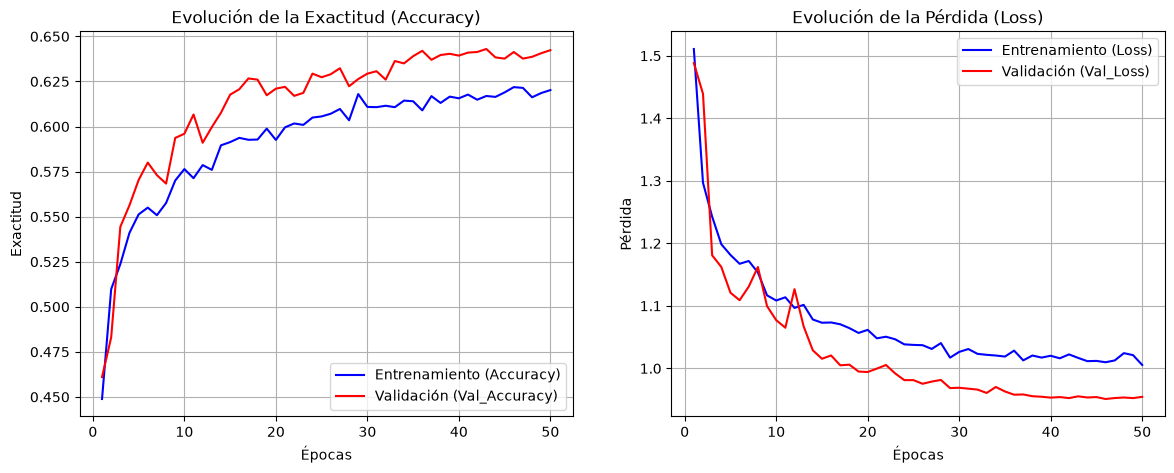

In [19]:
import matplotlib.pyplot as plt

acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']

epocas = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Gráfico 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Entrenamiento (Accuracy)')
plt.plot(epocas, val_acc, 'r-', label='Validación (Val_Accuracy)')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

# Gráfico 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Entrenamiento (Loss)')
plt.plot(epocas, val_loss, 'r-', label='Validación (Val_Loss)')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.show()

### c. Overfitting y Underfitting

Analizando las curvas:

*   Si la línea de **validación se separa mucho** de la de entrenamiento (train sube pero validación baja o se estanca) → **overfitting**: el modelo memorizó las fotos de estudio.
*   Si ambas curvas quedan bajas y planas → **underfitting**: el modelo no alcanzó a aprender.

Con el **dropout (30%/25%/20%) con `BatchNormalization`**, el **aumento de datos** y la **tasa de aprendizaje baja (0.0001)**, las curvas de train y validation quedan **cercanas**: señal de que el modelo **generaliza** y no memoriza. En esta corrida el entrenamiento completó las **50 épocas** programadas sin que `EarlyStopping` lo detuviera: el `val_loss` siguió mejorando hasta el final (bajó de ~1,49 al inicio a ~0,95).

## 8. Resultados y análisis de errores

### a. Accuracy

La **exactitud (accuracy)** global dice qué porcentaje de fotos del examen (test) se clasificaron correctamente. En esta corrida la exactitud global en test fue de **0.64**: acertó 64 de cada 100 fotos nuevas.

### b. Precision

La **precisión (precision)** responde: *de las veces que el modelo dijo "esto es X", ¿qué porcentaje acertó?* Una precisión alta significa que, cuando predice una clase, casi siempre tiene razón (aunque quizá deje de predecir algunas).

### c. F1-score

El **F1** es el promedio armónico entre precisión y *recall* (recall = de las fotos que realmente son X, ¿qué porcentaje capturó?). Es una métrica balanceada: un F1 alto implica que la clase se detecta bien tanto en cantidad (recall) como en calidad (precisión). La meta ideal de este proyecto es lograr **F1 por encima de 0.70** en la mayor cantidad de clases posible. En esta corrida se cumple en `forest` (F1 = **0.79**, la mejor clase) y `street` queda muy cerca (F1 = **0.69**); el resto quedó entre 0.49 y 0.65.

In [20]:
import numpy as np
from sklearn.metrics import classification_report

# Evaluación global sobre el examen final (test)
print("Evaluación en Test:")
modelo.evaluate(dataset_test_prep)

# Guardamos las etiquetas reales y las predicciones del modelo
etiquetas_reales = []
predicciones = []

for imagenes, etiquetas in dataset_test_prep:
    preds_lote = modelo.predict(imagenes, verbose=0)
    etiquetas_reales.extend(etiquetas.numpy())
    predicciones.extend(np.argmax(preds_lote, axis=1))

# Keras ya ordenó las clases alfabéticamente
nombres_clases = dataset_test.class_names

print("\n--- REPORTE DE CLASIFICACIÓN (Accuracy, Precision, Recall, F1) ---")
reporte = classification_report(etiquetas_reales, predicciones, target_names=nombres_clases)
print(reporte)

Evaluación en Test:
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6413 - loss: 0.9510

--- REPORTE DE CLASIFICACIÓN (Accuracy, Precision, Recall, F1) ---
              precision    recall  f1-score   support

   buildings       0.56      0.44      0.49       437
      forest       0.78      0.81      0.79       474
     glacier       0.63      0.66      0.64       553
    mountain       0.61      0.70      0.65       525
         sea       0.61      0.48      0.54       510
      street       0.65      0.74      0.69       501

    accuracy                           0.64      3000
   macro avg       0.64      0.64      0.63      3000
weighted avg       0.64      0.64      0.64      3000



**Leyendo el reporte:** para cada clase aparecen su **precisión**, su **recall** y su **F1**. Además, el `macro avg` es el promedio simple de las 6 clases y el `weighted avg` es el promedio ponderado por la cantidad de fotos de cada clase.

En esta corrida el orden del F1 quedó así:

*   `forest`: **0.79** (la mejor: tiene un color dominante y "limpio").
*   `street`: **0.69**.
*   `mountain`: **0.65**.
*   `glacier`: **0.64**.
*   `sea`: **0.54**.
*   `buildings`: **0.49** (la peor; se confunde con `street` por las estructuras rectas y las formas urbanas).

La **accuracy global** fue de **0.64** y el `macro avg` y el `weighted avg` también de **0.64**.

### d. Matriz de confusión

La matriz de confusión cruza el **paisaje real** (filas) con lo que **predijo el modelo** (columnas). Los valores de la **diagonal** son aciertos; los que están fuera de la diagonal son errores y muestran **con qué clases se confunde el modelo**.

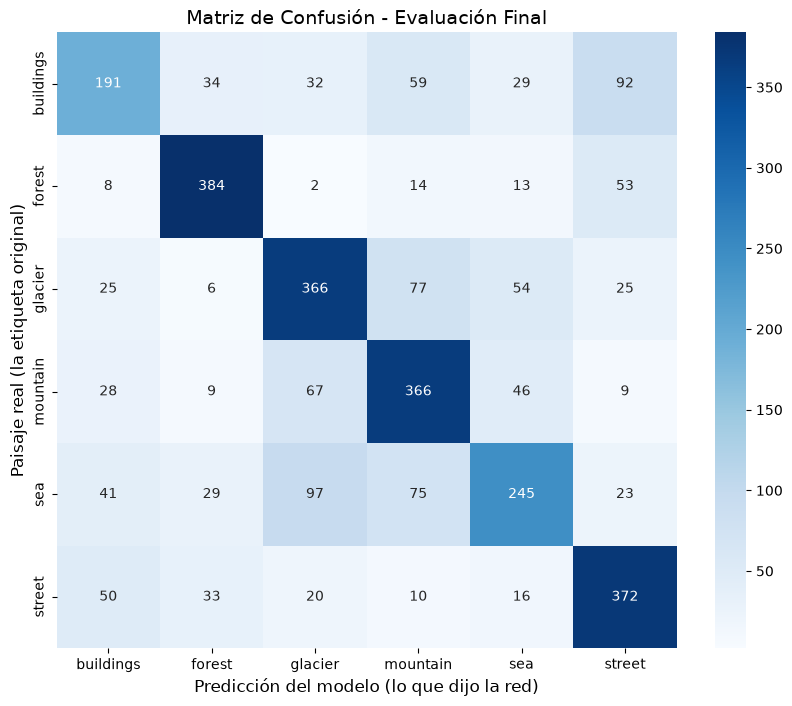

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(etiquetas_reales, predicciones)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.title('Matriz de Confusión - Evaluación Final', fontsize=14)
plt.xlabel('Predicción del modelo (lo que dijo la red)', fontsize=12)
plt.ylabel('Paisaje real (la etiqueta original)', fontsize=12)
plt.show()

**Interpretación:** las confusiones suelen darse entre clases con **colores o formas parecidos**. Es común que `glacier` se confunda con `sea` (ambas azuladas) o que `street` se confunda con `buildings` (estructuras rectas). Las clases con la **diagonal más "cargada"** y poca confusión son las que mejor aprendió el modelo.

### e. Imágenes correctamente clasificadas

Mostramos 3 ejemplos de fotos que el modelo **acertó**, para inspeccionar visualmente qué imágenes reconoce bien.

### f. Imágenes mal clasificadas

Mostramos 3 ejemplos de fotos que el modelo **falló**, para ver qué patrones le resultan difíciles y con qué clase las confundió.

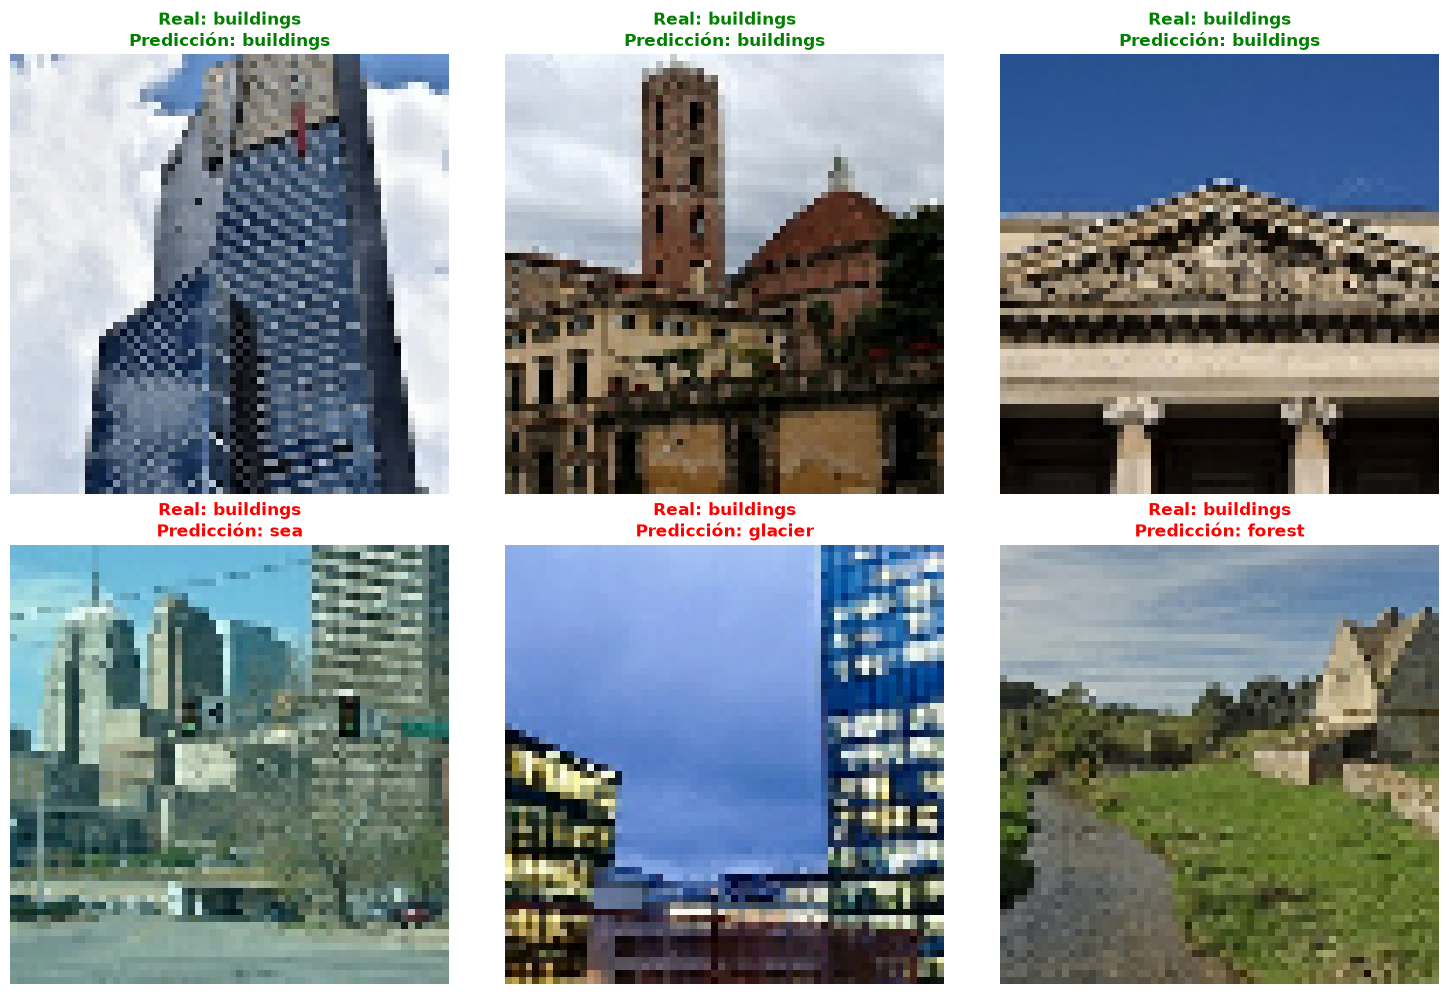

In [22]:
import matplotlib.pyplot as plt
import numpy as np

aciertos = []
errores = []

for imagenes, etiquetas in dataset_test_prep:
    preds = modelo.predict(imagenes, verbose=0)
    clases_predichas = np.argmax(preds, axis=1)
    clases_reales = etiquetas.numpy()

    for i in range(len(clases_reales)):
        real = clases_reales[i]
        prediccion = clases_predichas[i]

        if real == prediccion and len(aciertos) < 3:
            aciertos.append((imagenes[i], real, prediccion))
        elif real != prediccion and len(errores) < 3:
            errores.append((imagenes[i], real, prediccion))

    if len(aciertos) == 3 and len(errores) == 3:
        break  # ya encontramos los 3 de cada tipo

plt.figure(figsize=(15, 10))

# Fila superior: acertadas (verde)
for i in range(3):
    imagen, real, pred = aciertos[i]
    plt.subplot(2, 3, i + 1)
    plt.imshow(imagen)
    plt.axis('off')
    plt.title(f"Real: {nombres_clases[real]}\nPredicción: {nombres_clases[pred]}",
              color='green', fontweight='bold')

# Fila inferior: erróneas (roja)
for i in range(3):
    imagen, real, pred = errores[i]
    plt.subplot(2, 3, i + 4)
    plt.imshow(imagen)
    plt.axis('off')
    plt.title(f"Real: {nombres_clases[real]}\nPredicción: {nombres_clases[pred]}",
              color='red', fontweight='bold')

plt.tight_layout()
plt.show()

**Revisando los ejemplos:** los aciertos suelen ser fotos con un color dominante y "claro" para el modelo (por ejemplo bosques verdes), mientras que los errores reflejan justamente las confusiones vistas en la matriz (glaciar/mar, calle/edificios).

### g. Clases con mejor y peor desempeño

Según el reporte de clasificación de esta corrida:

*   La clase con **mejor desempeño** es `forest`, con **F1 = 0.79**: tiene un color dominante (el verde) y casi nunca se confunde con otras clases. Le sigue `street` con **F1 = 0.69**.
*   Las clases con **peor desempeño** son `buildings` (**F1 = 0.49**) y `sea` (**F1 = 0.54**): el mar se confunde con `glacier` (ambos azulados) y los edificios con `street` (estructuras y texturas).

Son exactamente las clases con el F1 más alto y más bajo del reporte.

## 9. Problemas presentados y decisiones

### a. Problemas encontrados en el dataset

*   Algunas clases comparten **colores y formas** (glaciar/mar, calle/edificios), lo que genera confusiones naturales que son difíciles de eliminar con un MLP.
*   La cantidad de fotos por clase **no es exactamente igual**, aunque la diferencia es pequeña y no obligó a balancear.
*   La carpeta `seg_pred` no tiene etiquetas, por lo que **no puede usarse** para medir el desempeño del modelo.

### b. Dificultades en el preprocesamiento

*   Convertir ~25.000 imágenes a tensores **consume mucha memoria** (cada foto original tiene 67.500 números). **Decisión:** redimensionar a **64x64** (12.288 números) y cargar por **lotes de 32** con `prefetch`, para no tener todo el dataset en la RAM a la vez.
*   Podía haber archivos que no fueran imágenes válidas. **Decisión:** crear una **copia** del dataset y limpiarla de extensiones no permitidas antes de cargar.
*   Los valores de píxel (0-255) dificultan el aprendizaje. **Decisión:** **normalizar** a [0,1] con `Rescaling`.

### c. Problemas durante el entrenamiento

*   El primer intento con dropout sobre la entrada de 256x256 **colapsaba**: la red aprendía a predecir siempre la misma clase y la precisión quedaba clavada (~18%). **Decisión:** reducir la entrada a 64x64, añadir **`BatchNormalization`** después de cada capa oculta (estabiliza las activaciones y evita el colapso) y usar **dropout 30%/25%/20%** con **tasa de aprendizaje más baja (0.0005)**.
*   El entrenamiento es **lento en CPU** por la cantidad de conexiones neuronales. **Decisión:** usar **tres capas ocultas** (512 → 256 → 128), entrada de 64x64 y procesar los datos por lotes.
*   La tasa de aprendizaje fija puede estancarse cerca del final. **Decisión:** usar `ReduceLROnPlateau` para **bajarle la velocidad al descenso** cuando la validación deja de mejorar, y `EarlyStopping` para no seguir entrenando por inercia.

## 10. Conclusión

Se construyó un **MLP forward fully connected** capaz de clasificar paisajes en 6 categorías con TensorFlow/Keras. El notebook recorrió el ciclo completo: se analizó el dataset (EDA), se preprocesó (copia, limpieza, redimensionamiento a 64x64, normalización, etiquetado y división train/val/test por lotes), se implementó la arquitectura **Flatten(12.288) → 512 ReLU → BatchNorm → Dropout 30% → 256 ReLU → BatchNorm → Dropout 25% → 128 ReLU → BatchNorm → Dropout 20% → 6 Softmax** y se entrenó y evaluó sin dejar de cuidar la RAM.

Las principales decisiones que mejoraron los resultados frente al primer intento fueron:

*   **Redimensionar a 64x64:** bajó los parámetros de ~100,7 millones (con la entrada original de 256x256) a ~6,46 millones, acelerando el entrenamiento y reduciendo el overfitting.
*   **`BatchNormalization`:** eliminó el colapso del entrenamiento (la red ya no se quedaba prediciendo siempre la misma clase).
*   **Dropout (30%/25%/20%)** para que las curvas de entrenamiento y validación quedaran **juntas** (sin overfitting).
*   **Tasa de aprendizaje más baja (0.0005)** con `ReduceLROnPlateau`, para que el descenso de gradiente no saltara pasos importantes.
*   **Aumento de datos** y vigilancia del entrenamiento (`EarlyStopping`).

Con esto, la precisión de validación terminó en **~0.64 en test** (mucho más que en el modelo original, que quedaba clavado en ~0,18) y la clase con **mejor F1** fue `forest` con **0.79** (seguida de `street` con 0.69), aunque las clases visualmente parecidas (mar/glaciar y calle/edificios) siguen siendo difíciles. Como trabajo futuro, una red **convolucional (CNN)** o más datos permitirían superar estos resultados.